In [5]:
!pip install shap -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✓")

All imports successful ✓


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club' dataset.
Path to dataset files: /kaggle/input/lending-club


In [8]:
import os

# See what files are in the downloaded folder
print(os.listdir(path))

['rejected_2007_to_2018Q4.csv.gz', 'accepted_2007_to_2018Q4.csv.gz', 'accepted_2007_to_2018q4.csv', 'rejected_2007_to_2018q4.csv']


In [11]:
df = pd.read_csv('/kaggle/input/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv', low_memory=False)
print(f"Shape: {df.shape}")
print(df['loan_status'].value_counts())

Shape: (2260701, 151)
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [12]:
# Keep only resolved loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Create binary target: 1 = default, 0 = paid back
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

print(f"Shape after filter: {df.shape}")
print(f"\nDefault rate: {df['default'].mean():.1%}")
print(df['default'].value_counts())

Shape after filter: (1345310, 152)

Default rate: 20.0%
default
0    1076751
1     268559
Name: count, dtype: int64


In [13]:
features = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'fico_range_low', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'emp_length',
    'home_ownership', 'purpose', 'term'
]

# Keep only feature columns + target
df_model = df[features + ['default']].copy()

print(f"Shape: {df_model.shape}")
print(f"\nMissing values:\n{df_model.isnull().sum()}")

Shape: (1345310, 16)

Missing values:
loan_amnt             0
int_rate              0
installment           0
annual_inc            0
dti                 374
fico_range_low        0
open_acc              0
pub_rec               0
revol_bal             0
revol_util          857
total_acc             0
emp_length        78511
home_ownership        0
purpose               0
term                  0
default               0
dtype: int64


In [14]:
# dti and revol_util — fill with median (small number of missing, safe to impute)
df_model['dti'] = df_model['dti'].fillna(df_model['dti'].median())
df_model['revol_util'] = df_model['revol_util'].fillna(df_model['revol_util'].median())

# emp_length — fill with 'Unknown' to preserve the signal
df_model['emp_length'] = df_model['emp_length'].fillna('Unknown')

# Confirm no more missing values
print(df_model.isnull().sum())

loan_amnt         0
int_rate          0
installment       0
annual_inc        0
dti               0
fico_range_low    0
open_acc          0
pub_rec           0
revol_bal         0
revol_util        0
total_acc         0
emp_length        0
home_ownership    0
purpose           0
term              0
default           0
dtype: int64


In [15]:
# See all unique values in a column
print(df_model['term'].unique())
print(df_model['emp_length'].unique())
print(df_model['home_ownership'].unique())
print(df_model['purpose'].unique())

[' 36 months' ' 60 months']
['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' 'Unknown']
['MORTGAGE' 'RENT' 'OWN' 'ANY' 'NONE' 'OTHER']
['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding' 'educational']


In [16]:
print(df_model.dtypes)

loan_amnt         float64
int_rate          float64
installment       float64
annual_inc        float64
dti               float64
fico_range_low    float64
open_acc          float64
pub_rec           float64
revol_bal         float64
revol_util        float64
total_acc         float64
emp_length         object
home_ownership     object
purpose            object
term               object
default             int64
dtype: object


In [17]:
# Convert term to numeric
df_model['term'] = df_model['term'].str.strip().str.replace(' months', '').astype(int)

# One-hot encode home_ownership and purpose
df_model = pd.get_dummies(df_model, columns=['home_ownership', 'purpose'], drop_first=True)

# Ordinal encode emp_length
emp_length_order = {
    'Unknown': 0, '< 1 year': 1, '1 year': 2, '2 years': 3,
    '3 years': 4, '4 years': 5, '5 years': 6, '6 years': 7,
    '7 years': 8, '8 years': 9, '9 years': 10, '10+ years': 11
}
df_model['emp_length'] = df_model['emp_length'].map(emp_length_order)

print(f"Shape: {df_model.shape}")
print(f"\nData types:\n{df_model.dtypes}")

Shape: (1345310, 32)

Data types:
loan_amnt                     float64
int_rate                      float64
installment                   float64
annual_inc                    float64
dti                           float64
fico_range_low                float64
open_acc                      float64
pub_rec                       float64
revol_bal                     float64
revol_util                    float64
total_acc                     float64
emp_length                      int64
term                            int64
default                         int64
home_ownership_MORTGAGE          bool
home_ownership_NONE              bool
home_ownership_OTHER             bool
home_ownership_OWN               bool
home_ownership_RENT              bool
purpose_credit_card              bool
purpose_debt_consolidation       bool
purpose_educational              bool
purpose_home_improvement         bool
purpose_house                    bool
purpose_major_purchase           bool
purpose_medical 

In [18]:
from sklearn.model_selection import train_test_split

# Separate features from target
X = df_model.drop('default', axis=1)
y = df_model['default']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.1%}")
print(f"Test default rate: {y_test.mean():.1%}")

X_train shape: (1076248, 31)
X_test shape: (269062, 31)
Train default rate: 20.0%
Test default rate: 20.0%


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Train logistic regression as baseline
lr = LogisticRegression(class_weight='balanced', max_iter=500)
lr.fit(X_train, y_train)

# Evaluate
lr_probs = lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

Logistic Regression AUC: 0.7010


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=4,
    eval_metric='auc',
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost AUC: {xgb_auc:.4f}")

XGBoost AUC: 0.7183


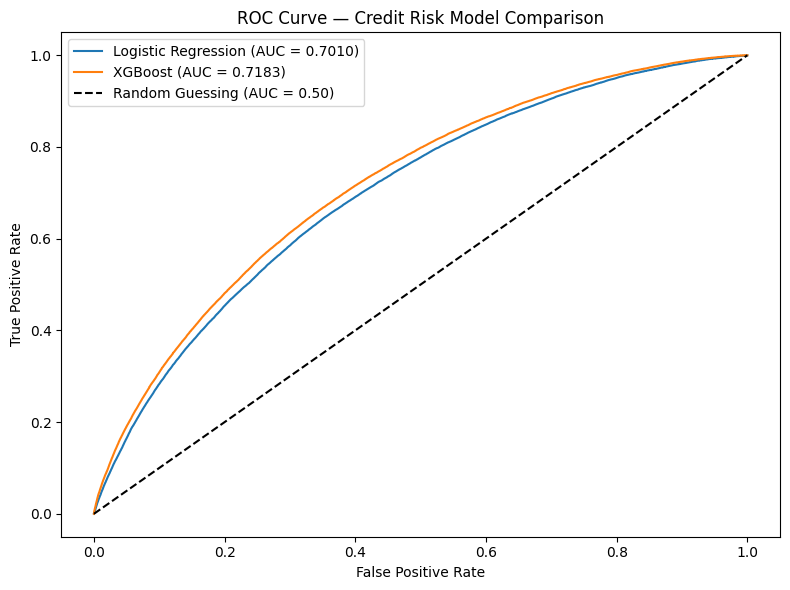

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Get ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# Plot
plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = 0.7010)')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = 0.7183)')
plt.plot([0,1], [0,1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Risk Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [22]:
import numpy as np

avg_loss = 6500  # average dollar loss per default
results = []

for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (xgb_probs >= thresh).astype(int)

    approved = (preds == 0).sum()
    rejected = (preds == 1).sum()
    approval_rate = approved / len(preds)

    defaults_caught = ((preds == 1) & (y_test == 1)).sum()
    defaults_missed = ((preds == 0) & (y_test == 1)).sum()
    loss_avoided = defaults_caught * avg_loss

    results.append({
        'threshold': round(thresh, 2),
        'approval_rate': approval_rate,
        'defaults_caught': defaults_caught,
        'defaults_missed': defaults_missed,
        'loss_avoided': loss_avoided
    })

df_thresh = pd.DataFrame(results)
print(df_thresh.head(10))

   threshold  approval_rate  defaults_caught  defaults_missed  loss_avoided
0       0.10       0.030525            53541              171     348016500
1       0.11       0.036720            53490              222     347685000
2       0.12       0.043510            53427              285     347275500
3       0.13       0.050557            53353              359     346794500
4       0.14       0.058254            53270              442     346255000
5       0.15       0.066304            53176              536     345644000
6       0.16       0.074990            53074              638     344981000
7       0.17       0.084148            52950              762     344175000
8       0.18       0.093558            52816              896     343304000
9       0.19       0.103407            52645             1067     342192500


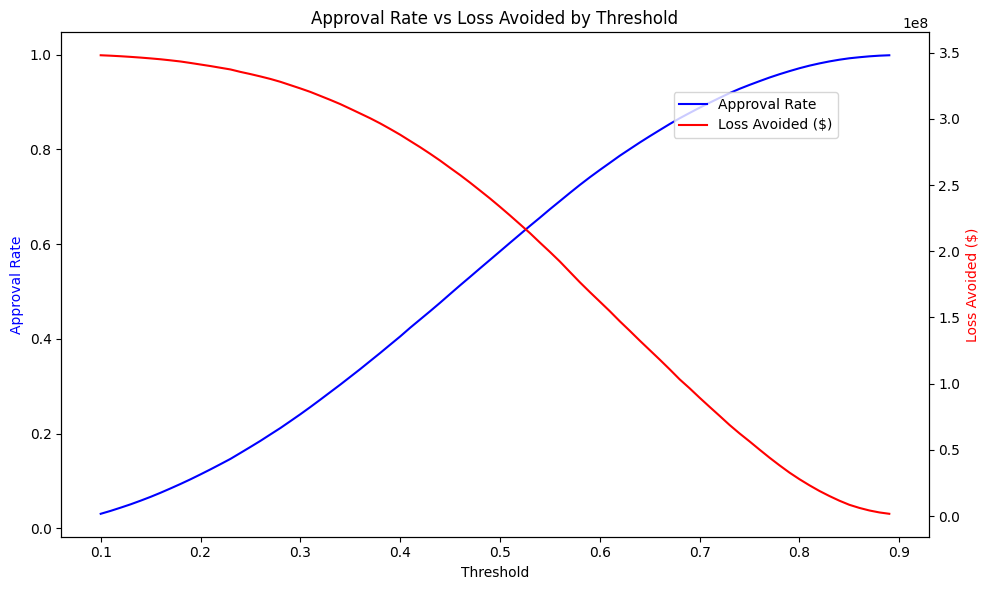

In [23]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(df_thresh['threshold'], df_thresh['approval_rate'],
         color='blue', label='Approval Rate')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Approval Rate', color='blue')

ax2 = ax1.twinx()
ax2.plot(df_thresh['threshold'], df_thresh['loss_avoided'],
         color='red', label='Loss Avoided ($)')
ax2.set_ylabel('Loss Avoided ($)', color='red')

plt.title('Approval Rate vs Loss Avoided by Threshold')
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150)
plt.show()

In [24]:
# Find threshold where we approve at least 70% of applicants
# while maximizing loss avoided
filtered = df_thresh[df_thresh['approval_rate'] >= 0.70]
optimal = filtered.loc[filtered['loss_avoided'].idxmax()]
print(optimal)

threshold          5.700000e-01
approval_rate      7.080078e-01
defaults_caught    2.836600e+04
defaults_missed    2.534600e+04
loss_avoided       1.843790e+08
Name: 47, dtype: float64


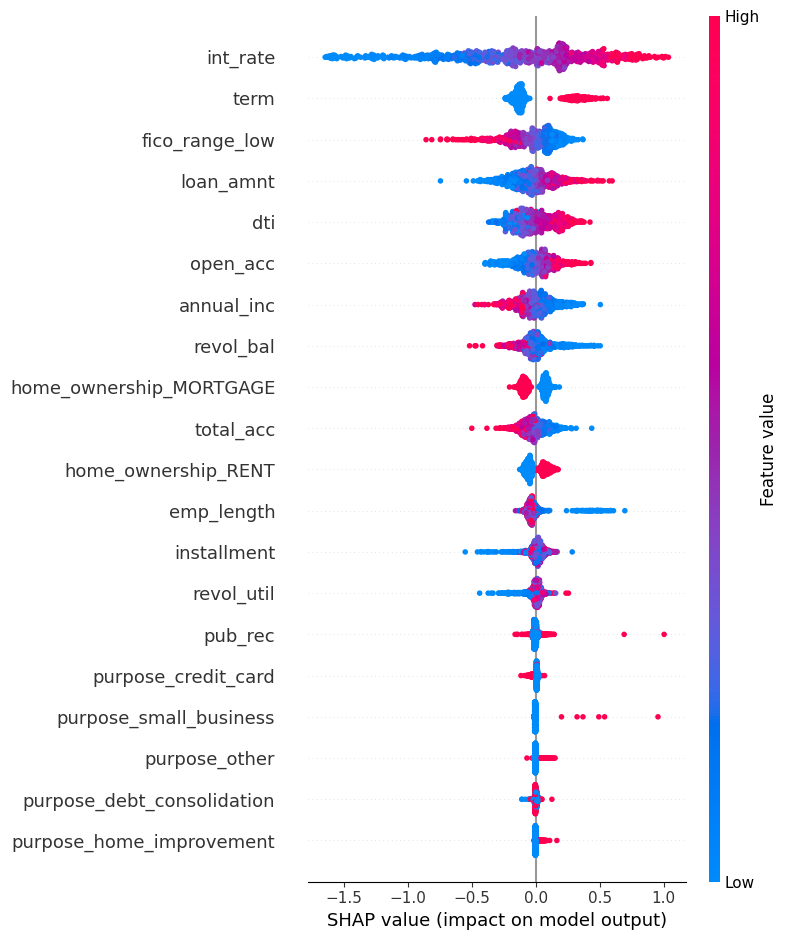

In [25]:
import shap

# Build explainer using your XGBoost model
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values on a sample of 1000 rows (full dataset is too slow)
sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(sample)

# Summary plot — shows which features matter most overall
shap.summary_plot(shap_values, sample, plot_type='dot')

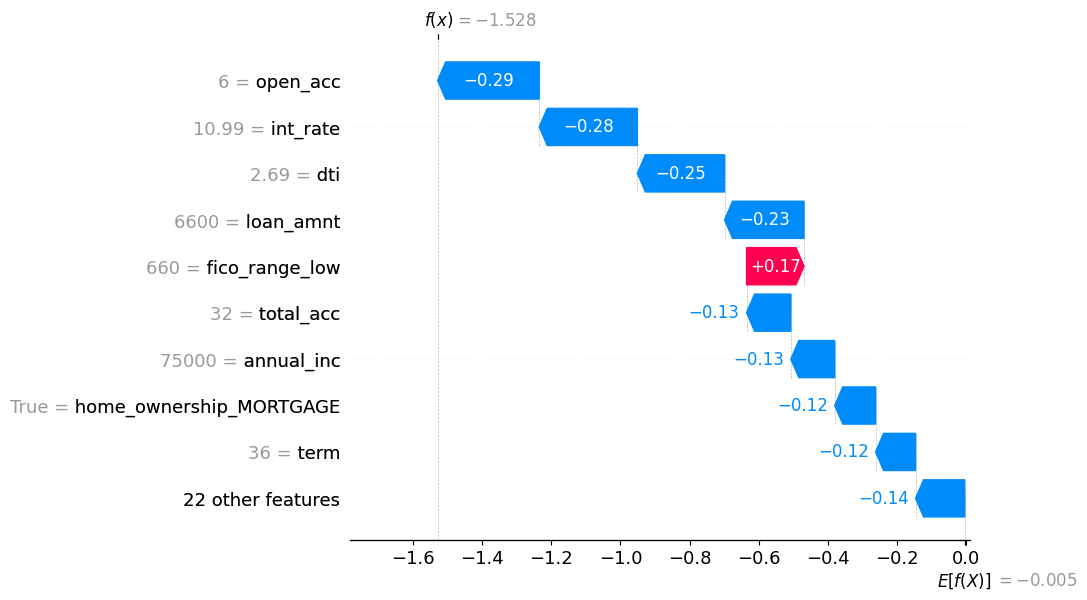

In [26]:
# Waterfall plot for single applicant
shap.plots.waterfall(explainer(sample)[0])